# Evaluation Plots — per-CellType benchmark

Compares four spatial deconvolution methods against the paired scRNA-seq
reference (`Seurat_Clusters.rds`) on **per-CellType** outputs.

Method palettes for the bar plots:
* **CoexpressDeconvolve** → viridis (teal/green)
* **Cell2Location** → plasma (magenta/pink)
* **STdeconvolve** → inferno (deep red)
* **Tangram** → flat orange (constant baseline)

Heatmaps use plain viridis throughout.

Methods background:
* **Tangram** — `ad_map`-weighted reference aggregation. `mode='cells'` collapses to reference per-CT pseudobulk → **GEX baseline** ≈ 1.0.
* **cell2location** — regression-model signature `inf_aver`. Also a **GEX baseline**.
* **STdeconvolve** — LDA β × topic_mass, collapsed via your Topic → CellType `map_synth`/`map_real`. Genuine learned per-CT GEX (HVG-only).
* **CoexpressDeconvolve** — `AggregateExpression(seurat_obj, group.by="CellType")` on in-silico cells. Full Visium gene space.


## 0 · Setup

In [40]:
suppressPackageStartupMessages({
  library(Seurat)
  library(Matrix)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(ggrepel)
  library(patchwork)
  library(pheatmap)
  library(viridis)
  library(RColorBrewer)
})

set.seed(42)

# Paths
ref_rds_path   <- "Seurat_Clusters.rds"
hvg_synth_path <- "fixed_hvgs.csv"
hvg_real_path  <- "fixed_hvgs_real.csv"
gt_counts_path <- "ground_truth_counts.csv"
gt_props_path  <- "ground_truth_proportions.csv"

# Methods
methods_all   <- c("tangram", "c2l", "stdeconv", "codeconv")
methods_count <- c("c2l", "codeconv")   # only these have nCells

method_label <- c(
  tangram  = "Tangram",
  c2l      = "Cell2Location",
  stdeconv = "STdeconvolve",
  codeconv = "CoexpressDeconvolve"
)

# Per-method cmap option 
method_cmap_option <- c(
  "Tangram"             = NA,           
  "Cell2Location"       = "viridis",
  "STdeconvolve"        = "viridis",
  "CoexpressDeconvolve" = "viridis"
)
tangram_orange <- "#FF8C00"

method_color <- c(
  "Tangram"             = tangram_orange,
  "Cell2Location"       = "#cc4778",
  "STdeconvolve"        = "#bb3754",
  "CoexpressDeconvolve" = "#21918c"
)

In [2]:
# Helpers

calc_ccc <- function(x, y) {
  ok <- is.finite(x) & is.finite(y)
  x <- x[ok]; y <- y[ok]
  if (length(x) < 2) return(NA_real_)
  if (sd(x) == 0 && sd(y) == 0) return(if (mean(x) == mean(y)) 1 else 0)
  if (sd(x) == 0 || sd(y) == 0) return(0)
  num <- 2 * cor(x, y) * sd(x) * sd(y)
  den <- var(x) + var(y) + (mean(x) - mean(y))^2
  num / den
}

safe_cor <- function(x, y, method = "pearson") {
  ok <- is.finite(x) & is.finite(y)
  x <- x[ok]; y <- y[ok]
  if (length(x) < 3) return(NA_real_)
  if (sd(x) == 0 || sd(y) == 0) return(NA_real_)
  suppressWarnings(cor(x, y, method = method))
}

jsd_row <- function(p, q, eps = 1e-12) {
  p <- p + eps; q <- q + eps
  p <- p / sum(p); q <- q / sum(q)
  m <- 0.5 * (p + q)
  0.5 * sum(p * log(p / m)) + 0.5 * sum(q * log(q / m))
}

upcase <- function(x) toupper(x)

clusters_to_drop <- c("B-cells")
                                       
read_celltype_gex <- function(path) {
  df <- read.csv(path, row.names = 1, check.names = FALSE)
  m  <- as.matrix(df)
  storage.mode(m) <- "numeric"
  rownames(m) <- upcase(rownames(m))
  m
}

build_ref_celltype_gex <- function(rds_path) {
  cat("Loading scRNA reference:", rds_path, "\n")
  ref <- readRDS(rds_path)
  if ("RNA" %in% names(ref@assays)) {
    DefaultAssay(ref) <- "RNA"
    suppressWarnings(ref <- JoinLayers(ref))
  }
  Idents(ref) <- ref$CellType
  agg <- AggregateExpression(ref, group.by = "CellType",
                             assays = DefaultAssay(ref))
  m <- as.matrix(agg[[1]])
  rownames(m) <- upcase(rownames(m))
  cat("Reference per-CT GEX:", nrow(m), "genes x", ncol(m), "CellTypes\n")
  m
}

to_log_cp10k <- function(mat) {
  s <- colSums(mat, na.rm = TRUE)
  s[s == 0] <- 1
  m <- sweep(mat, 2, s, "/") * 1e4
  log1p(m)
}

# Tangram label trim: "1.0" instead of "1.00" so labels fit outside the bar
fmt_r <- function(x, tol = 1e-3) {
  if (is.na(x)) return("NA")
  if (abs(x - 1) < tol) "1.0" else sprintf("%.2f", x)
}

## 1 · Build the reference per-CellType GEX

In [3]:
ref_ct <- build_ref_celltype_gex(ref_rds_path)
head(colnames(ref_ct))


Loading scRNA reference: Seurat_Clusters.rds 
Reference per-CT GEX: 36601 genes x 12 CellTypes


[1] "Tumor"               "Dividing Tumor"      "Luminal A"          
[4] "Luminal B"           "Myoepithelial Cells" "Ciliated Cells"

## 2 · Per-CellType GEX comparison — synthetic & real

In [4]:
compare_method_celltype <- function(method, scope, hvg_path, ref_ct) {
  fn <- sprintf("%s_%s_celltype_gex.csv", method, scope)
  if (!file.exists(fn)) {
    cat(sprintf("  [skip] %s/%s -- missing file %s\n", method, scope, fn))
    return(NULL)
  }
  pred <- read_celltype_gex(fn)

  hvgs <- upcase(readLines(hvg_path))
  common_genes <- Reduce(intersect, list(hvgs, rownames(pred), rownames(ref_ct)))
  if (length(common_genes) < 50) {
    cat(sprintf("  [skip] %s/%s -- only %d common HVGs\n",
                method, scope, length(common_genes)))
    return(NULL)
  }

  common_cts <- intersect(colnames(pred), colnames(ref_ct))
  common_cts <- setdiff(common_cts, clusters_to_drop)
  if (length(common_cts) < 2) {
    cat(sprintf("  [skip] %s/%s -- only %d common CellTypes\n",
                method, scope, length(common_cts)))
    return(NULL)
  }

  pred_sub <- pred[common_genes, common_cts, drop = FALSE]
  ref_sub  <- ref_ct[common_genes, common_cts, drop = FALSE]

  pred_log <- to_log_cp10k(pred_sub)
  ref_log  <- to_log_cp10k(ref_sub)

  cor_mat <- cor(pred_log, ref_log, method = "pearson")

  per_ct <- data.frame(
    Method   = method_label[[method]],
    Scope    = scope,
    CellType = common_cts,
    Pearson  = sapply(common_cts, function(ct) safe_cor(pred_log[, ct], ref_log[, ct])),
    Spearman = sapply(common_cts, function(ct) safe_cor(pred_log[, ct], ref_log[, ct], "spearman")),
    CCC      = sapply(common_cts, function(ct) calc_ccc(pred_log[, ct], ref_log[, ct])),
    Genes    = length(common_genes),
    stringsAsFactors = FALSE
  )
  rownames(per_ct) <- NULL

  list(method = method, scope = scope, label = method_label[[method]],
       cor_mat = cor_mat, per_ct = per_ct,
       pred_log = pred_log, ref_log = ref_log)
}

gex_results <- list()
for (m in methods_all) {
  for (sc in c("synth", "real")) {
    hvg_path <- if (sc == "synth") hvg_synth_path else hvg_real_path
    res <- compare_method_celltype(m, sc, hvg_path, ref_ct)
    if (!is.null(res)) gex_results[[paste(m, sc, sep = "_")]] <- res
  }
}

per_ct_df <- do.call(rbind, lapply(gex_results, function(r) r$per_ct))
rownames(per_ct_df) <- NULL
print(head(per_ct_df, 20))


    Method Scope            CellType Pearson  Spearman CCC Genes
1  Tangram synth               Tumor       1 0.9999976   1  3000
2  Tangram synth             T-cells       1 0.9999439   1  3000
3  Tangram synth         Fibroblasts       1 0.9999347   1  3000
4  Tangram synth      Dividing Tumor       1 0.9999977   1  3000
5  Tangram synth                TAMs       1 0.9999751   1  3000
6  Tangram synth Myoepithelial Cells       1 0.9998929   1  3000
7  Tangram synth           Luminal A       1 0.9999745   1  3000
8  Tangram synth   Endothelial Cells       1 0.9999904   1  3000
9  Tangram synth        Plasma Cells       1 0.9996112   1  3000
10 Tangram synth           Luminal B       1 0.9998157   1  3000
11 Tangram synth      Ciliated Cells       1 0.9990920   1  3000
12 Tangram  real               Tumor       1 0.9999726   1  2967
13 Tangram  real             T-cells       1 0.9995407   1  2967
14 Tangram  real         Fibroblasts       1 0.9999449   1  2967
15 Tangram  real      Div

### 2a — CT × CT correlation heatmaps

In [5]:
dir.create("HM", showWarnings = FALSE)

plot_corr_heatmap <- function(res, save_dir = "HM") {
  if (is.null(res)) return(invisible(NULL))
  m <- res$cor_mat
  fn <- file.path(save_dir,
                  sprintf("Eval_GEX_Heatmap_%s_%s.png", res$method, res$scope))
  pheatmap(m,
           color = viridis(100, option = "viridis"),
           border_color = NA,
           cluster_rows = TRUE,
           cluster_cols = TRUE,
           fontsize_row = 9, fontsize_col = 9,
           treeheight_row = 40, treeheight_col = 30,
           angle_col = 45,
           main = sprintf("%s (%s) — CT × CT log1p-CP10K Pearson",
                          res$label, res$scope),
           filename = fn, width = 7.5, height = 6.2)
  cat("Saved:", fn, "\n")
}

for (r in gex_results) plot_corr_heatmap(r)


Saved: HM/Eval_GEX_Heatmap_tangram_synth.png 
Saved: HM/Eval_GEX_Heatmap_tangram_real.png 
Saved: HM/Eval_GEX_Heatmap_c2l_synth.png 
Saved: HM/Eval_GEX_Heatmap_c2l_real.png 
Saved: HM/Eval_GEX_Heatmap_stdeconv_synth.png 
Saved: HM/Eval_GEX_Heatmap_stdeconv_real.png 
Saved: HM/Eval_GEX_Heatmap_codeconv_synth.png 
Saved: HM/Eval_GEX_Heatmap_codeconv_real.png 


### 2b — Pearson per CellType

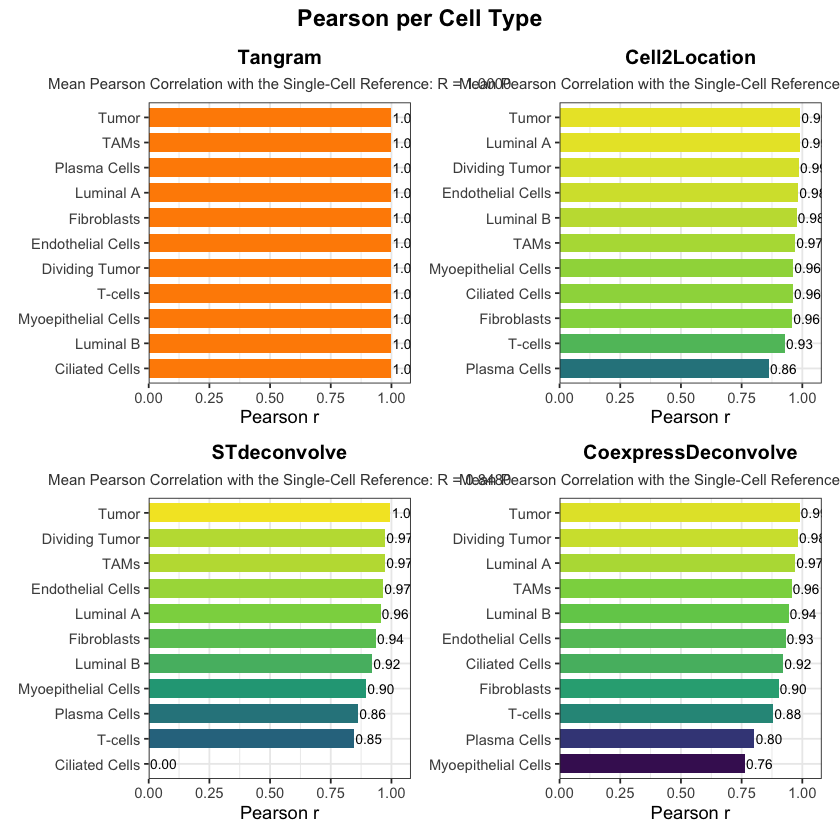

In [45]:
all_cts_ref <- setdiff(colnames(ref_ct), clusters_to_drop)

diag_rows <- list()
for (key in names(gex_results)) {
  if (grepl("_real", key)) next 
  
  res <- gex_results[[key]]
  sub <- res$per_ct
  bm <- data.frame(
    Method     = sub$Method,
    Scope      = sub$Scope,
    Spatial_CT = sub$CellType,
    Pearson    = sub$Pearson,
    stringsAsFactors = FALSE
  )
  missing_cts <- setdiff(all_cts_ref, bm$Spatial_CT)
  if (length(missing_cts) > 0) {
    bm <- rbind(bm, data.frame(
      Method = res$label, Scope = res$scope,
      Spatial_CT = missing_cts, Pearson = 0,
      stringsAsFactors = FALSE
    ))
  }
  diag_rows[[key]] <- bm
}
diag_df <- do.call(rbind, diag_rows)
rownames(diag_df) <- NULL

build_one_panel <- function(sd, method_name) {
  sd$label_txt <- sapply(sd$Pearson, fmt_r)
  opt <- method_cmap_option[[method_name]]
  mean_r <- mean(sd$Pearson, na.rm = TRUE)
  subtitle_txt <- sprintf(
    "Mean Pearson Correlation with the Single-Cell Reference: R = %.4f",
    mean_r)
  base <- ggplot(sd, aes(x = reorder(Spatial_CT, Pearson),
                         y = Pearson, fill = Pearson)) +
    geom_col(width = 0.75, color = NA) +
    geom_text(aes(label = label_txt), hjust = -0.05, size = 2.9) +
    coord_flip() +
    scale_y_continuous(limits = c(0, 1.08), expand = c(0, 0)) +
    theme_bw(base_size = 11) +
    theme(legend.position = "none",
          plot.title = element_text(face = "bold", size = 12,
                                    hjust = 0.5),
          plot.subtitle = element_text(size = 9, hjust = 0.5,
                                       color = "grey25")) +
    labs(title = method_name,
         subtitle = subtitle_txt,
         x = NULL, y = "Pearson r")
  if (is.na(opt)) {
    base + scale_fill_gradient(low = "#FFE0B2", high = tangram_orange,
                               limits = c(0.75, 1), oob = scales::squish)
  } else {
    base + scale_fill_viridis_c(option = opt, limits = c(0.75, 1), oob = scales::squish)
  }
}

plot_pearson_panels <- function(df, scope, plot_title) {
  sub <- df[df$Scope == scope, ]
  if (nrow(sub) == 0) return(invisible(NULL))
  method_order <- intersect(unname(method_label), unique(sub$Method))
  panels <- lapply(method_order, function(meth) {
    build_one_panel(sub[sub$Method == meth, ], meth)
  })
  patchwork::wrap_plots(panels, ncol = 2) +
    patchwork::plot_annotation(
      title = plot_title,
      theme = theme(plot.title = element_text(face = "bold", size = 14,
                                              hjust = 0.5))
    )
}

p_bars_synth <- plot_pearson_panels(diag_df, "synth",
                                    "Pearson per Cell Type")
ggsave("Eval_GEX_Pearson_synth.png", p_bars_synth,
       width = 10.5, height = 8.25, dpi = 600)
print(p_bars_synth)

## 3 · Cell-proportion accuracy

In [7]:
gt_props <- read.csv(gt_props_path, row.names = 1, check.names = FALSE)
cat("Ground-truth proportions:", nrow(gt_props), "spots,", ncol(gt_props), "CellTypes\n")

prop_overall_rows  <- list()
prop_per_type_rows <- list()

for (m in methods_all) {
  fn <- paste0(m, "_synth_props.csv")
  if (!file.exists(fn)) next
  pred <- read.csv(fn, row.names = 1, check.names = FALSE)

  cs <- intersect(rownames(gt_props), rownames(pred))
  ct <- intersect(colnames(gt_props), colnames(pred))
  ct <- setdiff(ct, clusters_to_drop)
  if (length(cs) == 0 || length(ct) == 0) next

  t <- as.matrix(gt_props[cs, ct]);  storage.mode(t) <- "numeric"
  p <- as.matrix(pred[cs, ct]);       storage.mode(p) <- "numeric"

  rs_t <- rowSums(t); rs_t[rs_t == 0] <- 1; t_n <- t / rs_t
  rs_p <- rowSums(p); rs_p[rs_p == 0] <- 1; p_n <- p / rs_p

  rmse_overall <- sqrt(mean((t_n - p_n)^2, na.rm = TRUE))
  rmse_per_ct  <- sqrt(colMeans((t_n - p_n)^2, na.rm = TRUE))
  jsd_vals     <- sapply(seq_len(nrow(t_n)), function(i) jsd_row(t_n[i, ], p_n[i, ]))

  prop_overall_rows[[length(prop_overall_rows) + 1]] <-
    data.frame(Method = method_label[[m]],
               RMSE = rmse_overall,
               JSD_median = median(jsd_vals, na.rm = TRUE),
               JSD_mean   = mean(jsd_vals, na.rm = TRUE))
  prop_per_type_rows[[length(prop_per_type_rows) + 1]] <-
    data.frame(Method = method_label[[m]],
               CellType = names(rmse_per_ct),
               RMSE = as.numeric(rmse_per_ct))
}

prop_overall_df  <- do.call(rbind, prop_overall_rows)
prop_per_type_df <- do.call(rbind, prop_per_type_rows)

print(prop_overall_df)


Ground-truth proportions: 2500 spots, 12 CellTypes
               Method       RMSE JSD_median   JSD_mean
1             Tangram 0.09191669 0.04785053 0.07848776
2       Cell2Location 0.10255083 0.03600051 0.06207537
3        STdeconvolve 0.12302026 0.06019355 0.08788457
4 CoexpressDeconvolve 0.14940546 0.11264598 0.13932701


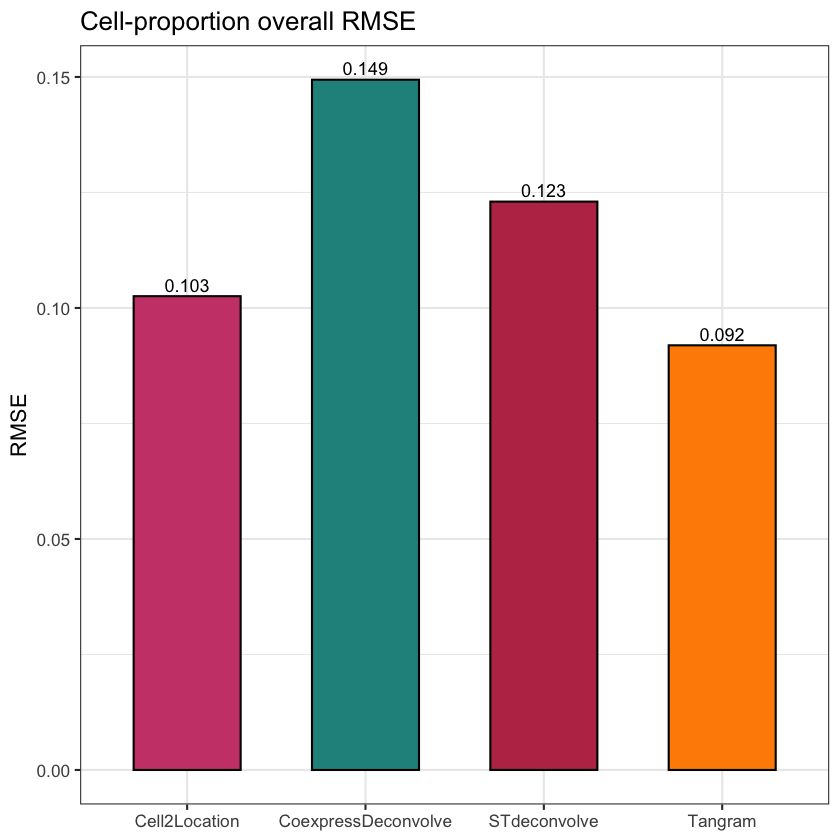

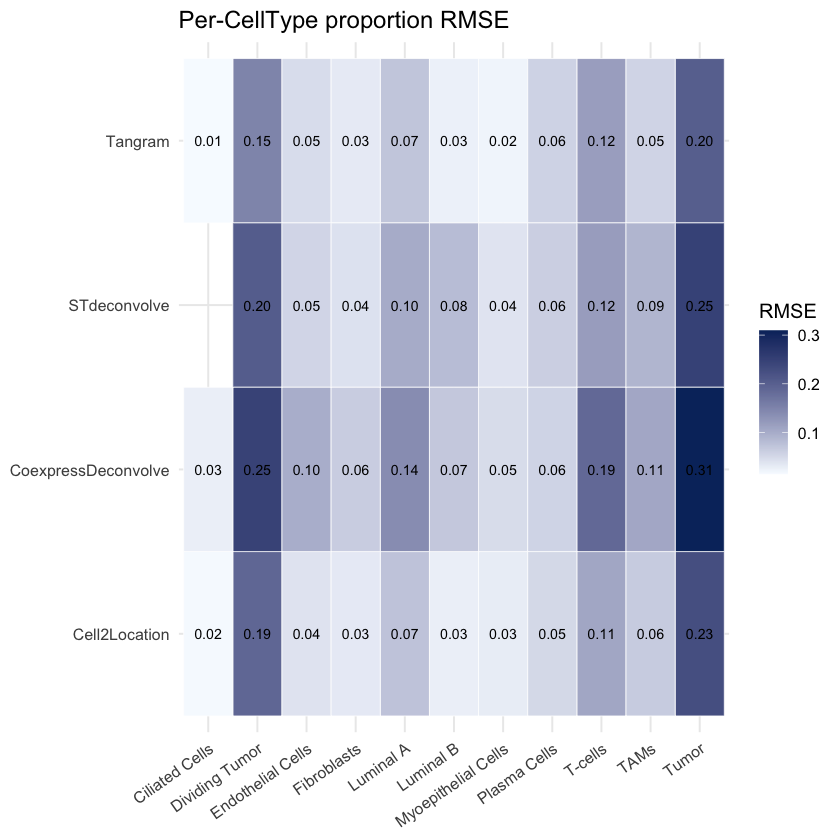

In [42]:
p_rmse <- ggplot(prop_overall_df, aes(x = Method, y = RMSE, fill = Method)) +
  geom_col(width = 0.6, color = "black") +
  geom_text(aes(label = sprintf("%.3f", RMSE)), vjust = -0.4, size = 3.8) +
  scale_fill_manual(values = method_color) +
  theme_bw(base_size = 13) +
  theme(legend.position = "none") +
  labs(title = "Cell-proportion overall RMSE",
       x = NULL, y = "RMSE")
ggsave("Eval_Props_RMSE.png", p_rmse, width = 12, height = 4.5, dpi = 600)
print(p_rmse)

p_per_ct <- ggplot(prop_per_type_df, aes(x = CellType, y = Method, fill = RMSE)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.2f", RMSE)), size = 3) +
  scale_fill_gradient(low = "#f7fbff", high = "#08306b") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1)) +
  labs(title = "Per-CellType proportion RMSE",
       x = NULL, y = NULL, fill = "RMSE")
ggsave("Eval_Props_PerCellType_RMSE.png", p_per_ct,
       width = 10, height = 4.25, dpi = 600)
print(p_per_ct)


## 4 · Absolute cell counts per spot — c2l + CoexpressDeconvolve

Saved: Eval_Counts_PerSpot_Grid_c2l_synth.png 
Saved: Eval_Counts_PerSpot_Grid_codeconv_synth.png 


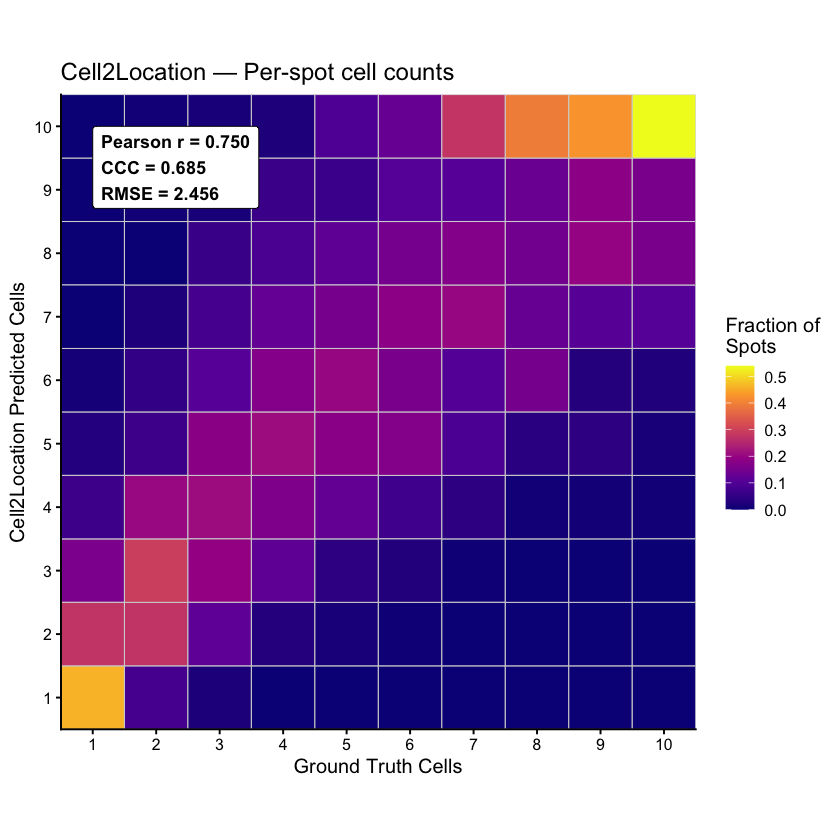

               Method RMSE_total_per_spot RMSE_cellcounts
1       Cell2Location            2.456420       0.8441241
2 CoexpressDeconvolve            1.671077       0.8082240


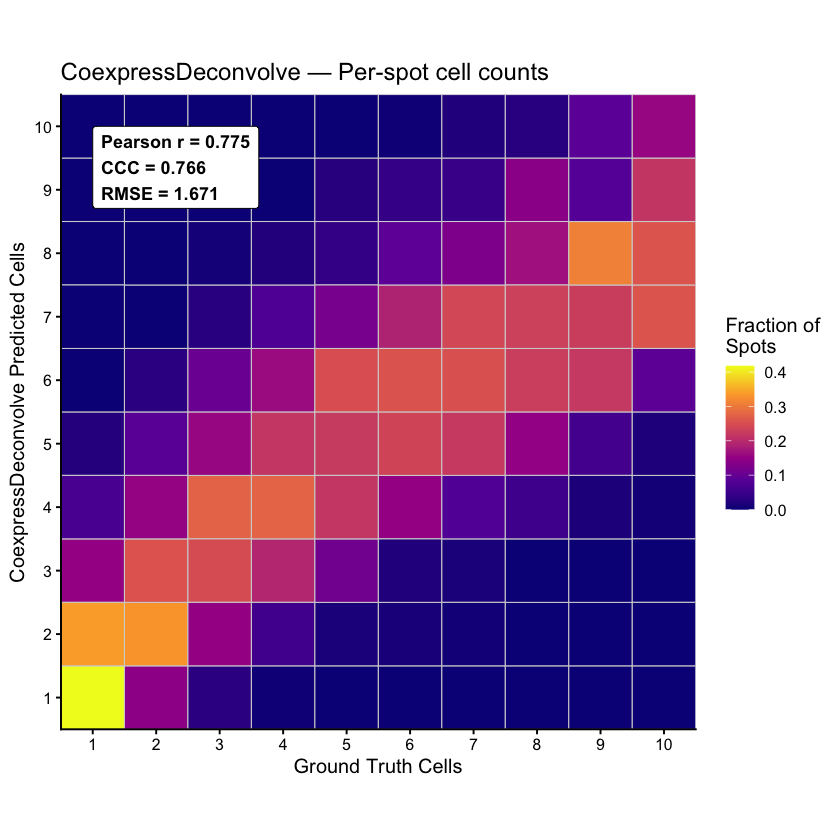

In [31]:
gt_counts <- read.csv(gt_counts_path, row.names = 1, check.names = FALSE)

count_overall_rows <- list()
count_per_ct_rows  <- list()

# 4a. Normalized 2D grid plots 
plot_counts_grid <- function(m, scope, gt_counts, cmap_opt) {
  fn <- sprintf("%s_%s_counts.csv", m, scope)
  if (!file.exists(fn)) return(invisible(NULL))
  pred <- read.csv(fn, row.names = 1, check.names = FALSE)

  cs <- intersect(rownames(gt_counts), rownames(pred))
  ct <- intersect(setdiff(colnames(gt_counts), "Total_Cells"), colnames(pred))
  ct <- setdiff(ct, clusters_to_drop)
  if (length(cs) == 0 || length(ct) == 0) return(invisible(NULL))

  t <- as.matrix(gt_counts[cs, ct]);  storage.mode(t) <- "numeric"
  p <- as.matrix(pred[cs, ct]);        storage.mode(p) <- "numeric"

  t_tot <- rowSums(t); p_tot <- rowSums(p)

  # Stats on ALL spots
  r    <- safe_cor(t_tot, p_tot)
  ccc  <- calc_ccc(t_tot, p_tot)
  rmse <- sqrt(mean((t_tot - p_tot)^2, na.rm = TRUE))
  rmse_cell <- sqrt(mean((t - p)^2, na.rm = TRUE))
  rmse_perct <- sqrt(colMeans((t - p)^2, na.rm = TRUE))

  count_overall_rows[[length(count_overall_rows) + 1]] <<-
    data.frame(Method = method_label[[m]],
               RMSE_total_per_spot = rmse,
               RMSE_cellcounts     = rmse_cell)
  count_per_ct_rows[[length(count_per_ct_rows) + 1]] <<-
    data.frame(Method = method_label[[m]],
               CellType = names(rmse_perct),
               RMSE = as.numeric(rmse_perct))

  valid <- p_tot > 0
  xv <- pmin(pmax(round(t_tot[valid]), 1), 10)
  yv <- pmin(pmax(round(p_tot[valid]), 1), 10)
  grid_df <- as.data.frame(
    table(GT = factor(xv, levels = 1:10),
          Pred = factor(yv, levels = 1:10))
  )
  grid_df$GT   <- as.numeric(as.character(grid_df$GT))
  grid_df$Pred <- as.numeric(as.character(grid_df$Pred))

  col_tot <- aggregate(Freq ~ GT, grid_df, sum)
  names(col_tot)[2] <- "ColTotal"
  grid_df <- merge(grid_df, col_tot, by = "GT")
  grid_df$Frac <- ifelse(grid_df$ColTotal > 0,
                         grid_df$Freq / grid_df$ColTotal, 0)

  stats_txt <- sprintf("Pearson r = %.3f\nCCC = %.3f\nRMSE = %.3f",
                       r, ccc, rmse)

  p_plot <- ggplot(grid_df, aes(x = GT, y = Pred, fill = Frac)) +
    geom_tile(color = "lightgray", linewidth = 0.3) +
    scale_fill_viridis_c(option = cmap_opt,
                         name = "Fraction of\nSpots") +
    coord_fixed(xlim = c(0.5, 10.5), ylim = c(0.5, 10.5),
                expand = FALSE) +
    scale_x_continuous(breaks = 1:10) +
    scale_y_continuous(breaks = 1:10) +
    annotate("label", x = 1, y = 10, label = stats_txt,
             hjust = 0, vjust = 1, fill = "white", color = "black",
             fontface = "bold", size = 3.8,
             label.padding = unit(0.4, "lines")) +
    theme_classic(base_size = 12) +
    theme(panel.grid = element_blank()) +
    labs(title = sprintf("%s — Per-spot cell counts", method_label[[m]]),
         x = "Ground Truth Cells",
         y = sprintf("%s Predicted Cells", method_label[[m]]))

  out <- sprintf("Eval_Counts_PerSpot_Grid_%s_%s.png", m, scope)
  ggsave(out, p_plot, width = 6.5, height = 5, dpi = 600)
  cat("Saved:", out, "\n")
  p_plot
}

# Run on synthetic only 
for (m in methods_count) {
  cmap_opt <- if (m == "c2l") "plasma" else "plasma"
  p_g <- plot_counts_grid(m, "synth", gt_counts, cmap_opt)
  if (!is.null(p_g)) print(p_g)
}

count_overall_df <- do.call(rbind, count_overall_rows)
count_per_ct_df  <- do.call(rbind, count_per_ct_rows)
print(count_overall_df)


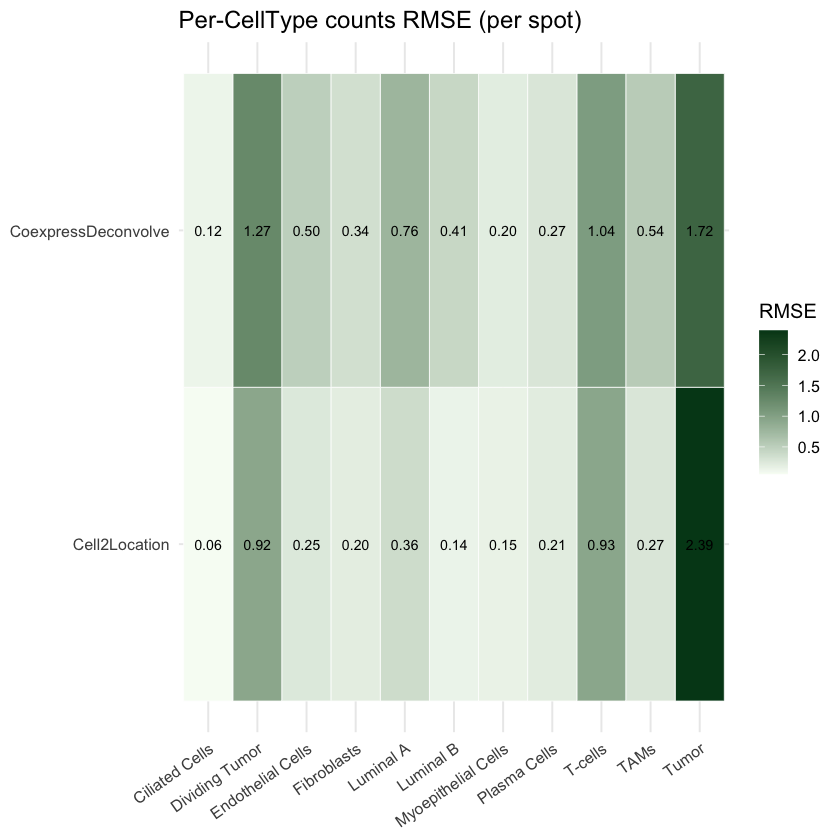

In [17]:
# 4b. Per-CellType counts RMSE heatmap
p_count_ct <- ggplot(count_per_ct_df, aes(x = CellType, y = Method, fill = RMSE)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.2f", RMSE)), size = 3) +
  scale_fill_gradient(low = "#f7fcf5", high = "#00441b") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1)) +
  labs(title = "Per-CellType counts RMSE (per spot)",
       x = NULL, y = NULL, fill = "RMSE")
ggsave("Eval_Counts_PerCellType_RMSE.png", p_count_ct,
       width = 9, height = 2.6, dpi = 600)
print(p_count_ct)


## 5 · Per-slide cluster totals

In [11]:
slide_results_rows <- list()
slide_points_rows  <- list()

for (m in methods_count) {
  fn_counts <- paste0(m, "_synth_counts.csv")
  if (!file.exists(fn_counts)) next
  pred <- read.csv(fn_counts, row.names = 1, check.names = FALSE)

  cs <- intersect(rownames(gt_counts), rownames(pred))
  ct <- intersect(setdiff(colnames(gt_counts), "Total_Cells"), colnames(pred))
  ct <- setdiff(ct, clusters_to_drop)
  if (length(cs) == 0 || length(ct) == 0) next

  t <- as.matrix(gt_counts[cs, ct]);  storage.mode(t) <- "numeric"
  p <- as.matrix(pred[cs, ct]);        storage.mode(p) <- "numeric"
  if (m == "c2l") p <- round(p)

  t_slide <- colSums(t, na.rm = TRUE)
  p_slide <- colSums(p, na.rm = TRUE)

  slide_results_rows[[length(slide_results_rows) + 1]] <- data.frame(
    Method   = method_label[[m]],
    Pearson  = safe_cor(t_slide, p_slide),
    Spearman = safe_cor(t_slide, p_slide, "spearman"),
    CCC      = calc_ccc(t_slide, p_slide),
    stringsAsFactors = FALSE
  )
  slide_points_rows[[length(slide_points_rows) + 1]] <- data.frame(
    Method  = method_label[[m]],
    CellType = ct,
    True_Cells = t_slide,
    Pred_Cells = p_slide,
    stringsAsFactors = FALSE
  )
}

slide_df  <- do.call(rbind, slide_results_rows)
slide_pts <- do.call(rbind, slide_points_rows)
print(slide_df)


               Method   Pearson  Spearman       CCC
1       Cell2Location 0.9760189 0.9977247 0.9144298
2 CoexpressDeconvolve 0.9577535 0.9636364 0.9516722


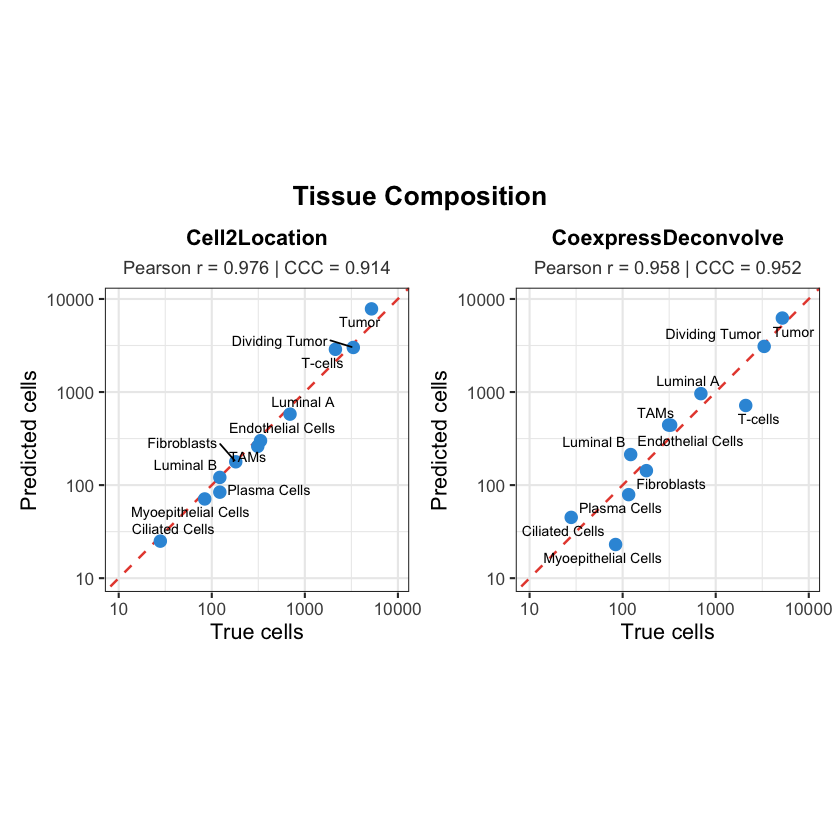

In [12]:
# Tissue Composition
build_tissue_panel <- function(method_label_str, pts_sub, r_val, ccc_val) {

  combined_x <- slide_pts$True_Cells + 1
  combined_y <- slide_pts$Pred_Cells + 1
  lo <- 10
  hi <- max(combined_x, combined_y, na.rm = TRUE) * 1.2

  ggplot(pts_sub, aes(x = True_Cells + 1, y = Pred_Cells + 1, label = CellType)) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed",
                color = "#e74c3c", linewidth = 0.7) +
    geom_point(color = "#3498db", size = 3) +
    geom_text_repel(size = 3, max.overlaps = 20, seed = 42) +
    scale_x_log10(limits = c(lo, hi)) +
    scale_y_log10(limits = c(lo, hi)) +
    theme_bw(base_size = 13) +
    theme(aspect.ratio = 1,
          plot.title = element_text(face = "bold", hjust = 0.5, size = 13),
          plot.subtitle = element_text(hjust = 0.5, size = 11,
                                       color = "grey25")) +
    labs(title = method_label_str,
         subtitle = sprintf("Pearson r = %.3f | CCC = %.3f", r_val, ccc_val),
         x = "True cells", y = "Predicted cells")
}

# One panel per method
panel_list <- list()
for (m in methods_count) {
  lbl <- method_label[[m]]
  pts <- slide_pts[slide_pts$Method == lbl, ]
  if (nrow(pts) == 0) next
  row_stats <- slide_df[slide_df$Method == lbl, ]
  panel_list[[lbl]] <- build_tissue_panel(lbl, pts,
                                          row_stats$Pearson,
                                          row_stats$CCC)
}

p_slide <- patchwork::wrap_plots(panel_list, ncol = length(panel_list)) +
  patchwork::plot_annotation(
    title = "Tissue Composition",
    theme = theme(plot.title = element_text(face = "bold", size = 16,
                                            hjust = 0.5))
  )

ggsave("Eval_Slide_ClusterTotals.png", p_slide,
       width = 5.5 * length(panel_list), height = 6, dpi = 600)
print(p_slide)


## 6 · Summary table

In [13]:
bits <- list()

if (exists("per_ct_df")) {
  agg_gex <- per_ct_df %>%
    group_by(Method, Scope) %>%
    summarise(median_Pearson = median(Pearson, na.rm = TRUE),
              median_CCC     = median(CCC,     na.rm = TRUE),
              mean_Pearson   = mean(Pearson,   na.rm = TRUE),
              mean_CCC       = mean(CCC,       na.rm = TRUE),
              .groups = "drop") %>%
    pivot_longer(c(median_Pearson, median_CCC, mean_Pearson, mean_CCC),
                 names_to = "metric", values_to = "value") %>%
    mutate(metric = paste0("GEX_", Scope, "_", metric)) %>%
    select(Method, metric, value)
  bits[["gex"]] <- agg_gex
}

if (exists("prop_overall_df")) {
  bits[["props"]] <- prop_overall_df %>%
    pivot_longer(-Method, names_to = "metric", values_to = "value") %>%
    mutate(metric = paste0("Props_", metric))
}

if (exists("count_overall_df")) {
  bits[["counts"]] <- count_overall_df %>%
    pivot_longer(-Method, names_to = "metric", values_to = "value") %>%
    mutate(metric = paste0("Counts_", metric))
}

if (exists("slide_df")) {
  bits[["slide"]] <- slide_df %>%
    select(Method, Pearson, Spearman, CCC) %>%
    pivot_longer(-Method, names_to = "metric", values_to = "value") %>%
    mutate(metric = paste0("SlideClusterTotals_", metric))
}

long_summary <- do.call(rbind, bits)
wide_summary <- pivot_wider(long_summary, names_from = "metric",
                            values_from = "value")
write.csv(wide_summary, "evaluation_summary.csv", row.names = FALSE)
write.csv(long_summary, "evaluation_summary_long.csv", row.names = FALSE)
write.csv(per_ct_df,   "evaluation_perCellType_GEX.csv", row.names = FALSE)

cat("Wrote evaluation_summary.csv:", ncol(wide_summary) - 1,
    "metrics for", nrow(wide_summary), "methods.\n\n")
print(as.data.frame(wide_summary))


Wrote evaluation_summary.csv: 16 metrics for 4 methods.

               Method GEX_real_median_Pearson GEX_real_median_CCC
1       Cell2Location               0.8247869           0.7961698
2 CoexpressDeconvolve               0.6929542           0.6706720
3        STdeconvolve               0.7604965           0.7337959
4             Tangram               1.0000000           1.0000000
  GEX_real_mean_Pearson GEX_real_mean_CCC GEX_synth_median_Pearson
1             0.8232426         0.8153497                0.9703905
2             0.7347129         0.7141763                0.9313853
3             0.7206220         0.6918566                0.9456179
4             1.0000000         1.0000000                1.0000000
  GEX_synth_median_CCC GEX_synth_mean_Pearson GEX_synth_mean_CCC Props_RMSE
1            0.9618498              0.9609528          0.9421404 0.10255083
2            0.9300926              0.9129132          0.9052587 0.14940546
3            0.9336766              0.9327745     

## 7 · Reading the results

* **Tangram + Cell2Location** = intentional GEX baselines (Tangram by
  `mode='cells'` collapses to the reference; c2l ships `inf_aver`).
* **STdeconvolve + CoexpressDeconvolve** carry the real GEX learning signal.
* Proportions: all four methods. Counts / slide totals: c2l + CoexpressDeconvolve only (the others don't produce nCells natively).
